# ECG Foundation Model benchmark

## Goal
Review reproducible, patient-independent multi-label ECG results. No training or test-set retuning is performed in this notebook.

## Setup
Run the completed benchmark first. Sources: PTB-XL 1.0.3, official ECGFounder. Paths are relative to the repository, and all displayed metrics come from saved real experiment outputs.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / 'results').exists():
    ROOT = ROOT.parent
assert (ROOT / 'results/metrics.csv').exists(), 'Run the complete benchmark first'

## Steps
### 1. Inspect the cohort
Official folds 1–8 / 9 / 10; exclude records without mapped diagnostic labels. Patient counts refer to retained eligible ECGs.

In [2]:
audit = json.loads((ROOT / 'results/data_audit.json').read_text())
display(pd.DataFrame(audit['splits']).T[['records','patients']])
print('Excluded without diagnostic labels:', audit['excluded_no_diagnostic_label'])

,records,patients
train,17084,14823
validation,2146,1917
test,2158,1877


Excluded without diagnostic labels: 411


### 2. Compare actual held-out results
Mean ± sample SD is reported for three seeds at 1–25%. At 100%, SD is undefined because only one seed was run.

In [3]:
summary = pd.read_csv(ROOT / 'results/summary.csv')
display(summary.round(4))

,model,fraction,n_seeds,auroc_mean,auroc_sd,auprc_mean,auprc_sd,f1_mean,f1_sd
0,linear_probe,0.05,3,0.8986,0.0036,0.7604,0.0067,0.7046,0.0085
1,linear_probe,0.10,3,0.9070,0.0020,0.7750,0.0054,0.7117,0.0011
2,linear_probe,1.00,1,0.9207,NaN,0.8053,NaN,0.7361,NaN
3,pretrained,0.01,3,0.8537,0.0085,0.6648,0.0178,0.6331,0.0107
4,pretrained,0.05,3,0.8877,0.0057,0.7383,0.0112,0.6947,0.0048
5,pretrained,0.10,3,0.9014,0.0024,0.7698,0.0054,0.7137,0.0020
6,pretrained,0.25,3,0.9157,0.0002,0.8005,0.0015,0.7315,0.0024
7,pretrained,1.00,1,0.9274,NaN,0.8211,NaN,0.7464,NaN
8,scratch,0.01,3,0.8117,0.0136,0.5858,0.0248,0.5827,0.0149
9,scratch,0.05,3,0.8531,0.0076,0.6675,0.0145,0.6305,0.0140


### 3. Inspect label efficiency
The x-axis is the percentage of training patients, not ECG records. Error bars show training/subsampling seed variability.

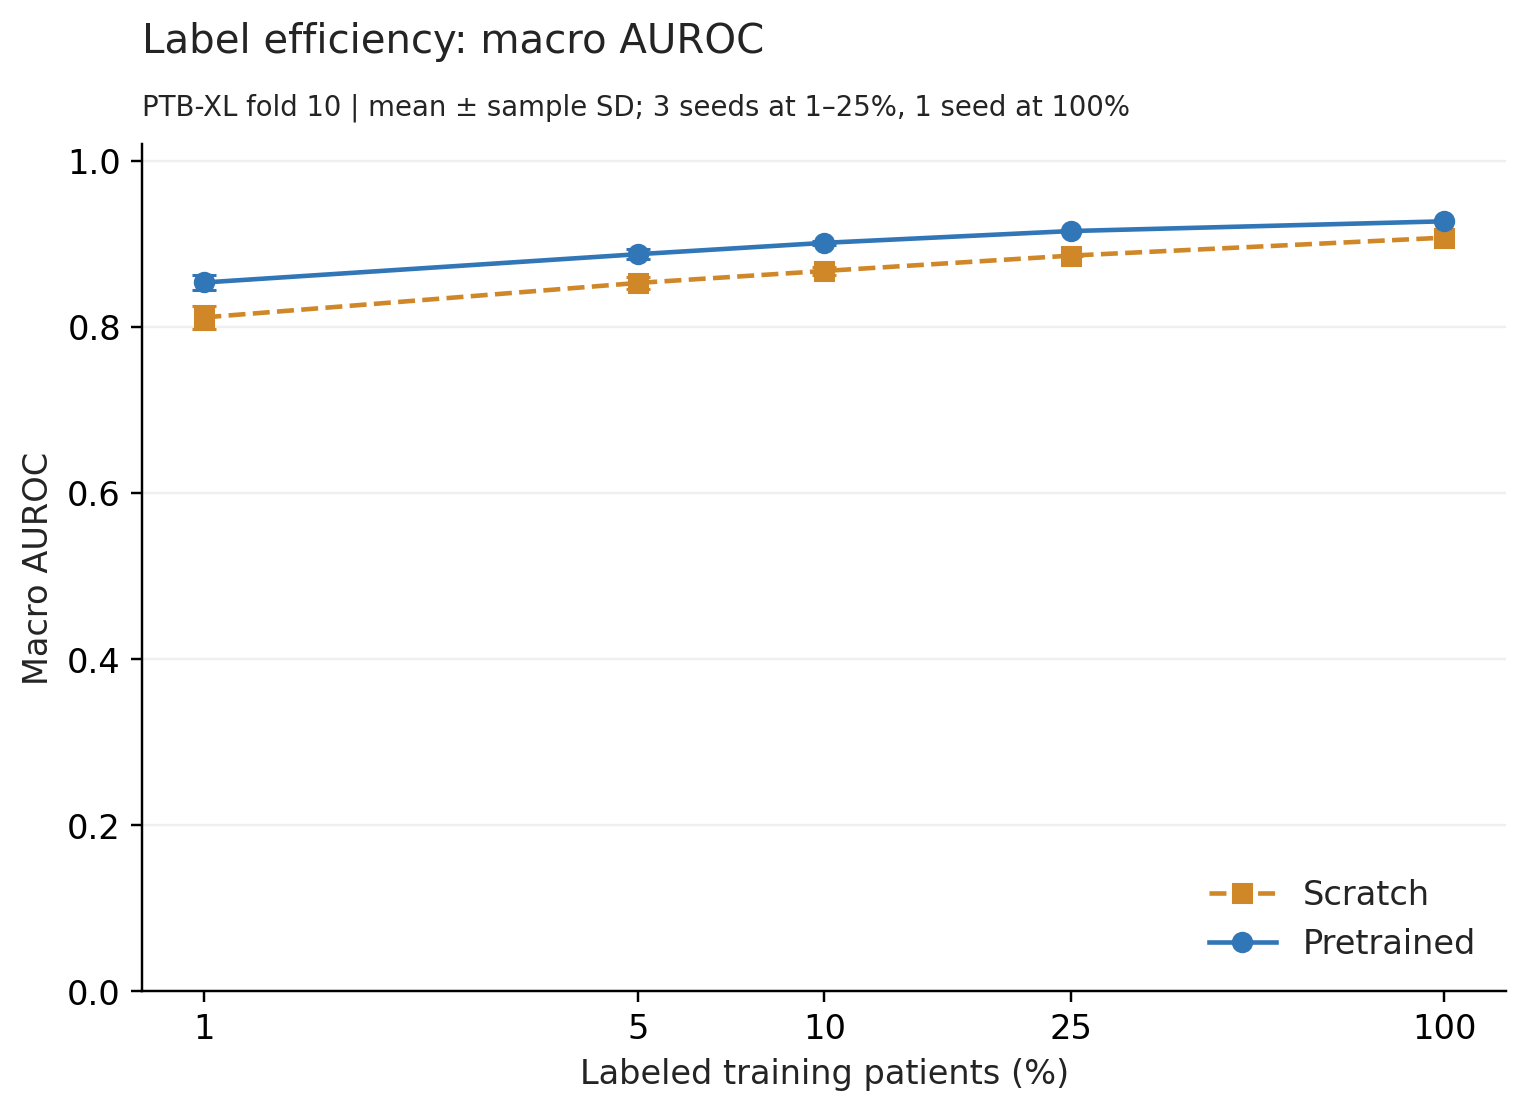

In [4]:
display(Image(filename=str(ROOT / 'figures/label_efficiency.png')))

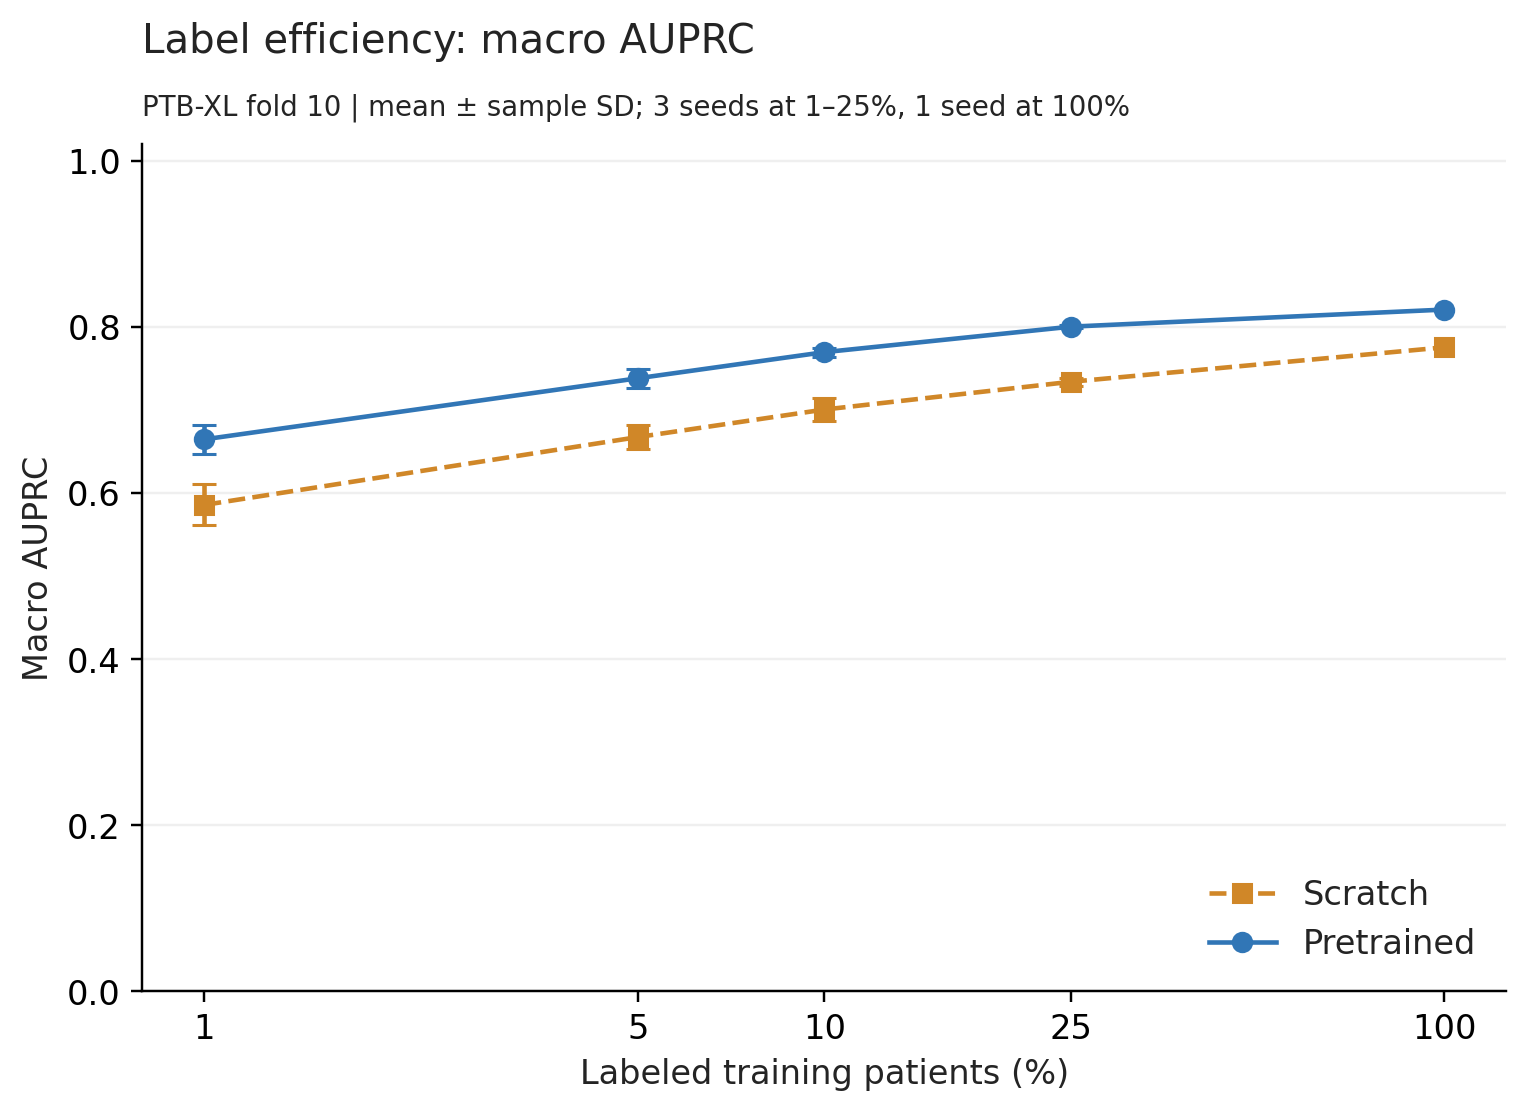

In [5]:
display(Image(filename=str(ROOT / 'figures/auprc.png')))

### 4. Inspect disease-specific results
Five independent labels; one ECG can contribute to multiple positive groups.

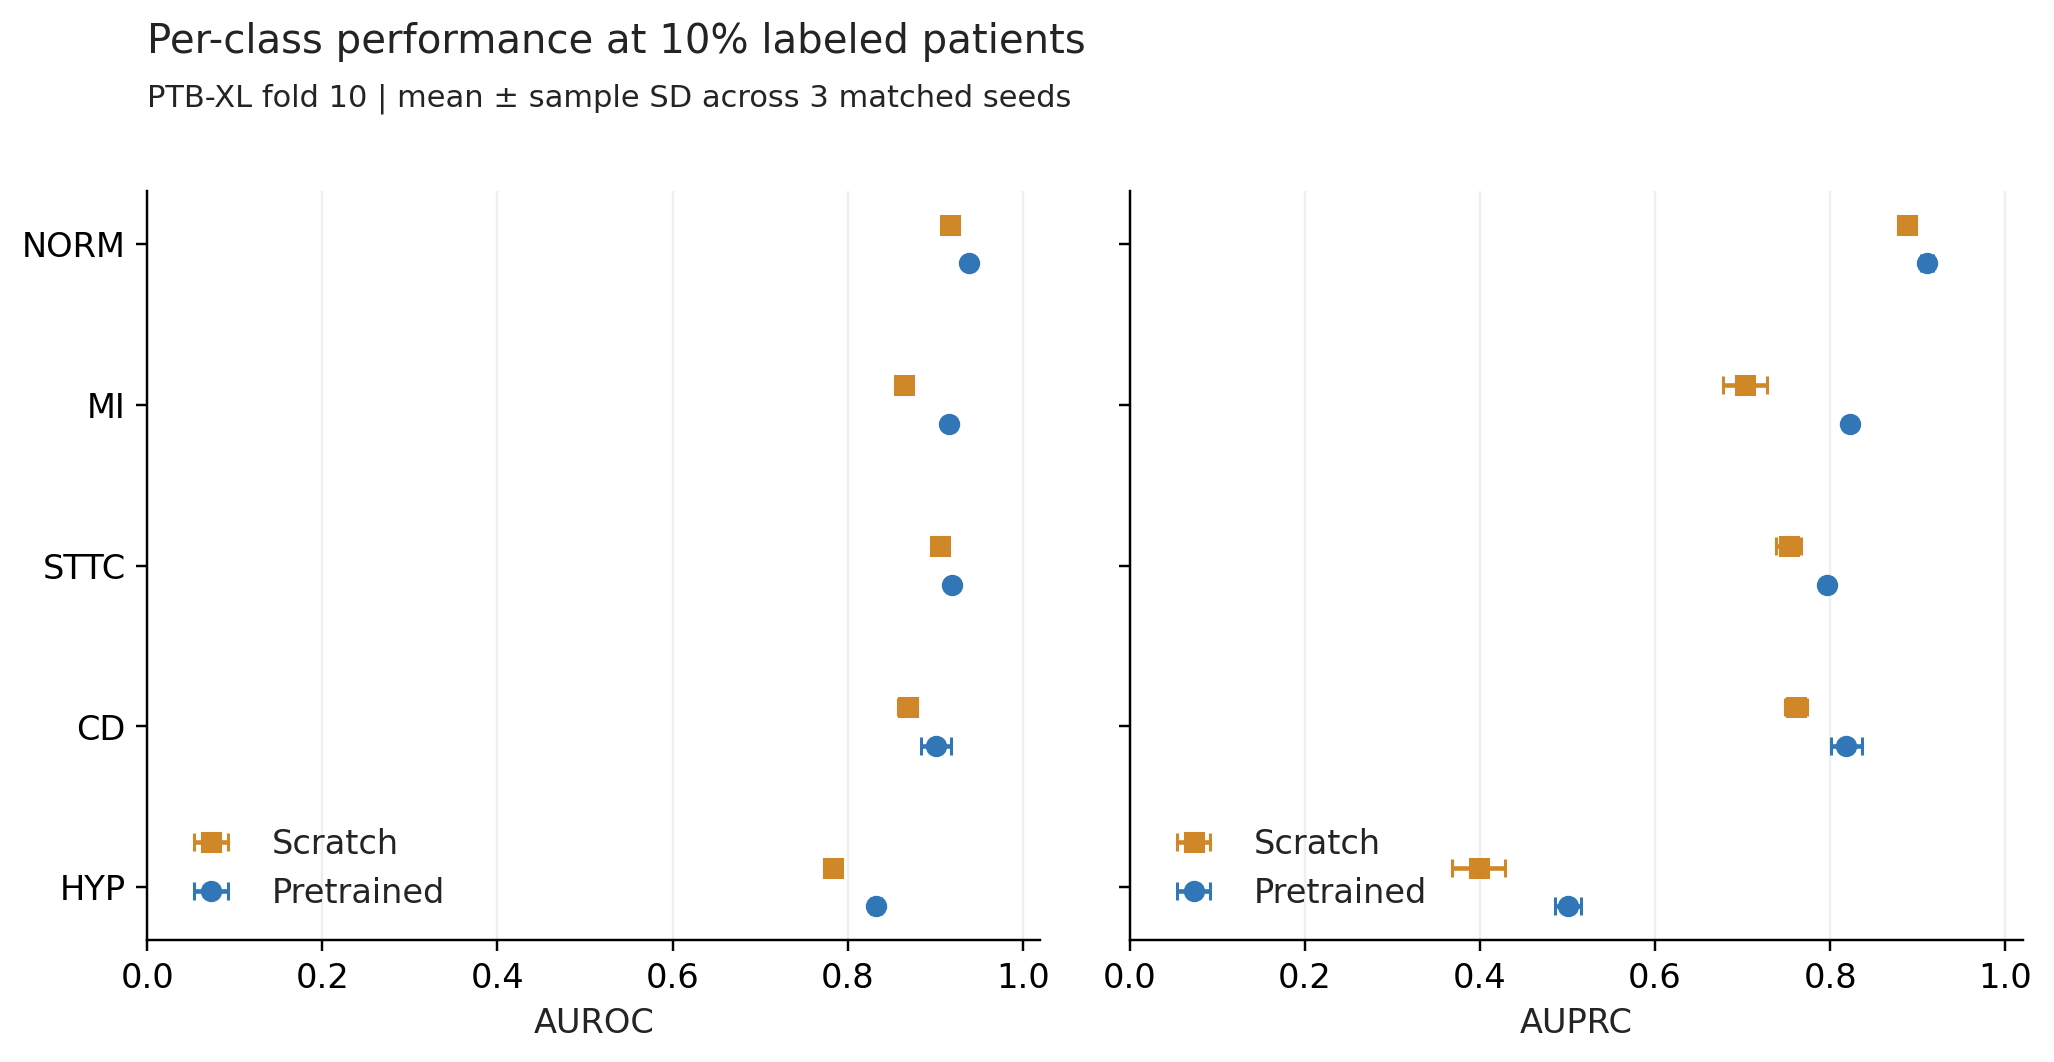

In [6]:
display(Image(filename=str(ROOT / 'figures/per_class.png')))

## Checks
All 26 full-fine-tuning conditions and 7 linear probes must be present. A separate test lock records weights and thresholds before evaluation.

In [7]:
metrics = pd.read_csv(ROOT / 'results/metrics.csv')
assert len(metrics) == 33
assert not metrics[['model','fraction','seed']].duplicated().any()
assert metrics['macro_auroc'].between(0,1).all()
lock = json.loads((ROOT / 'results/test_lock.json').read_text())
assert sum(r['group']=='main' for r in lock['runs']) == 33
assert sum(r['group']=='convergence' for r in lock['runs']) == 2
print('33 main/probe runs and 2 budget-sensitivity runs locked.')

33 main/probe runs and 2 budget-sensitivity runs locked.


## Next Steps
Interpret label efficiency as a discrete descriptive comparison, not statistical equivalence. Check training-budget diagnostics before claiming convergence. Robustness is post-preprocessing input corruption; patient bootstrap uncertainty is conditional on fitted models. See `experiments/PROTOCOL.md` for limitations.

In [8]:
display(json.loads((ROOT / 'results/label_efficiency_gain.json').read_text()))

{'definition': 'Smallest tested patient fraction whose mean AUROC >= scratch 100% AUROC; descriptive, not statistical equivalence',
 'scratch_100_auroc': 0.9076873274718624,
 'pretrained_min_tested_fraction': 0.25,
 'label_reduction': 0.75,
 'gain_factor': 4.0}